In [1]:
!pip install imbalanced-learn --quiet

import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

s3 = boto3.client('s3')
BUCKET = 'gridsense-azhuk-test'

print('Libraries loaded successfully')

Libraries loaded successfully


In [3]:
## EIA DATA with ERCOT Region Only
eia_files = [
    'eia/EIA930_BALANCE_2022_Jan_Jun.csv',
    'eia/EIA930_BALANCE_2022_Jul_Dec.csv',
    'eia/EIA930_BALANCE_2023_Jan_Jun.csv',
    'eia/EIA930_BALANCE_2023_Jul_Dec.csv',
    'eia/EIA930_BALANCE_2024_Jan_Jun.csv',
    'eia/EIA930_BALANCE_2024_Jul_Dec.csv',
]


# Columns for modeling
key_cols = [
    'Balancing Authority',
    'UTC Time at End of Hour',
    'Demand (MW)',
    'Net Generation (MW)',
    'Net Generation (MW) from Solar without Integrated Battery Storage',
    'Net Generation (MW) from Wind without Integrated Battery Storage',
    'Net Generation (MW) from Nuclear',
    'Net Generation (MW) from Hydropower Excluding Pumped Storage',
]

dfs = []
for file in eia_files:
    print(f'Loading {file}...')
    obj = s3.get_object(Bucket=BUCKET, Key=file)
    df_temp = pd.read_csv(obj['Body'], low_memory=False)
    # Filtering to ERCOT only
    df_temp = df_temp[df_temp['Balancing Authority'] == 'ERCO']
    # Keep only key columns that exist
    existing_cols = [c for c in key_cols if c in df_temp.columns]
    dfs.append(df_temp[existing_cols])

eia = pd.concat(dfs, ignore_index=True)
print(f'\nEIA ERCOT shape: {eia.shape}')
print(eia.head(3))

Loading eia/EIA930_BALANCE_2022_Jan_Jun.csv...
Loading eia/EIA930_BALANCE_2022_Jul_Dec.csv...
Loading eia/EIA930_BALANCE_2023_Jan_Jun.csv...
Loading eia/EIA930_BALANCE_2023_Jul_Dec.csv...
Loading eia/EIA930_BALANCE_2024_Jan_Jun.csv...
Loading eia/EIA930_BALANCE_2024_Jul_Dec.csv...

EIA ERCOT shape: (26304, 8)
  Balancing Authority UTC Time at End of Hour  Demand (MW)  \
0                ERCO   01/01/2022 7:00:00 AM      38123.0   
1                ERCO   01/01/2022 8:00:00 AM      37122.0   
2                ERCO   01/01/2022 9:00:00 AM      35936.0   

   Net Generation (MW)  Net Generation (MW) from Nuclear  \
0              37963.0                            5099.0   
1              36757.0                            5099.0   
2              35826.0                            5099.0   

   Net Generation (MW) from Solar without Integrated Battery Storage  \
0                                                NaN                   
1                                                NaN   

In [4]:
# Scrubbing EIA Data
# Changing column names to shorter cleaner names
eia = eia.rename(columns={
    'UTC Time at End of Hour': 'timestamp',
    'Demand (MW)': 'demand',
    'Net Generation (MW)': 'net_gen',
    'Net Generation (MW) from Solar without Integrated Battery Storage': 'solar_gen',
    'Net Generation (MW) from Wind without Integrated Battery Storage': 'wind_gen',
    'Net Generation (MW) from Nuclear': 'nuclear_gen',
    'Net Generation (MW) from Hydropower Excluding Pumped Storage': 'hydro_gen',
    'Balancing Authority': 'balancing_authority'
})

# Parsing timestamp to UTC datetime for better format
eia['timestamp'] = pd.to_datetime(eia['timestamp'], utc=True)

# Removing duplicates
before = len(eia)
eia = eia.drop_duplicates(subset=['timestamp'])
print(f'Duplicates removed: {before - len(eia)}')

# Sorting by time
eia = eia.sort_values('timestamp').reset_index(drop=True)

# As Solar and Wind are 83% null for ERCOT in earlier years filling with 0
# THe goal is to supplement these by NREL solar and Open-Meteo wind features
for col in ['solar_gen', 'wind_gen', 'nuclear_gen', 'hydro_gen']:
    null_pct = eia[col].isnull().mean() * 100
    print(f'{col}: {null_pct:.1f}% null — filling with 0')
    eia[col] = eia[col].fillna(0)

# Filling demand nulls with forward fill with a maximum of 3 consecutive hours
eia['demand'] = eia['demand'].fillna(method='ffill', limit=3)
eia['net_gen'] = eia['net_gen'].fillna(method='ffill', limit=3)

# Dropping any remaining nulls
eia = eia.dropna(subset=['demand', 'net_gen'])

print(f'\nEIA shape after scrubbing: {eia.shape}')
print(f'Null values remaining:')
print(eia.isnull().sum())

Duplicates removed: 0
solar_gen: 83.2% null — filling with 0
wind_gen: 83.2% null — filling with 0
nuclear_gen: 0.0% null — filling with 0
hydro_gen: 83.2% null — filling with 0

EIA shape after scrubbing: (26304, 8)
Null values remaining:
balancing_authority    0
timestamp              0
demand                 0
net_gen                0
nuclear_gen            0
solar_gen              0
wind_gen               0
hydro_gen              0
dtype: int64


In [7]:
# Loading and scrubbing Open-Meteo Data
obj = s3.get_object(Bucket=BUCKET, Key='openmeteo/openmeteo_weather_2022_2024.csv')
raw = obj['Body'].read().decode('utf-8')
weather = pd.read_csv(StringIO(raw), skiprows=3)

# Renaming columnds for simplicity
weather = weather.rename(columns={
    'time': 'timestamp',
    'temperature_2m (°C)': 'temperature',
    'windspeed_10m (km/h)': 'windspeed_10m',
    'windspeed_100m (km/h)': 'windspeed_100m',
    'cloudcover (%)': 'cloudcover',
    'shortwave_radiation (W/m²)': 'shortwave_radiation',
    'precipitation (mm)': 'precipitation',
    'windgusts_10m (km/h)': 'windgusts'
})

# Dropping unneeded columns
weather = weather.drop(columns=['precipitation', 'windgusts'], errors='ignore')

# Parsing timestamp of Open-Meteo to UTC
weather['timestamp'] = pd.to_datetime(weather['timestamp'], utc=True)

# Removing duplicates
weather = weather.drop_duplicates(subset=['timestamp'])
weather = weather.sort_values('timestamp').reset_index(drop=True)

print(f'Open-Meteo shape: {weather.shape}')
print(f'Null values: {weather.isnull().sum().sum()}')
print(weather.head(3))

Open-Meteo shape: (26304, 6)
Null values: 0
                  timestamp  temperature  windspeed_10m  windspeed_100m  \
0 2022-01-01 00:00:00+00:00         23.9           17.7            33.4   
1 2022-01-01 01:00:00+00:00         22.7           18.4            33.2   
2 2022-01-01 02:00:00+00:00         22.0           18.3            32.7   

   cloudcover  shortwave_radiation  
0          48                 19.0  
1          54                  0.0  
2          42                  0.0  


In [8]:
# Loading and scrubbing NREL Data
nrel_files = [
    'nrel/1545408_30.30_-97.71_2022_ff25f18395b8033aeb23ca6f1c973bf4.csv',
    'nrel/1545408_30.30_-97.71_2023_fa0d07fb0da2452c557f67cfe8cd69cd.csv',
    'nrel/1545408_30.30_-97.71_2024_34550f7445646d50c7e4e3be9f680d03.csv',
]

nrel_dfs = []
for file in nrel_files:
    obj = s3.get_object(Bucket=BUCKET, Key=file)
# NREL CSVs have 2 metadata rows
    df_temp = pd.read_csv(obj['Body'], skiprows=2)
    nrel_dfs.append(df_temp)

nrel = pd.concat(nrel_dfs, ignore_index=True)

# Timestamp parsing from Year, Month, Day, Hour columns
nrel['timestamp'] = pd.to_datetime({
    'year': nrel['Year'],
    'month': nrel['Month'],
    'day': nrel['Day'],
    'hour': nrel['Hour']
}, utc=True)

# Keeping only solar baseline columns
nrel = nrel[['timestamp', 'GHI', 'DNI', 'DHI', 'Cloud Type']].copy()
nrel = nrel.rename(columns={
    'GHI': 'ghi',
    'DNI': 'dni',
    'DHI': 'dhi',
    'Cloud Type': 'cloud_type'
})

# Removing duplicates and sorting
nrel = nrel.drop_duplicates(subset=['timestamp'])
nrel = nrel.sort_values('timestamp').reset_index(drop=True)

print(f'NREL shape: {nrel.shape}')
print(f'Null values: {nrel.isnull().sum().sum()}')
print(nrel.head(3))

NREL shape: (26280, 5)
Null values: 0
                  timestamp  ghi  dni  dhi  cloud_type
0 2022-01-01 00:00:00+00:00    0    0    0           8
1 2022-01-01 01:00:00+00:00    0    0    0           1
2 2022-01-01 02:00:00+00:00    0    0    0           7


In [9]:
# Merging EIA and Open-Meteo
df = pd.merge(eia, weather, on='timestamp', how='inner')
print(f'After EIA + Weather merge: {df.shape}')

# Merging with NREL
df = pd.merge(df, nrel, on='timestamp', how='inner')
print(f'After NREL merge: {df.shape}')

# Verifying date range
print(f'\nDate range: {df["timestamp"].min()} to {df["timestamp"].max()}')
print(f'\nNull values after merge:')
print(df.isnull().sum())

After EIA + Weather merge: (26297, 13)
After NREL merge: (26273, 17)

Date range: 2022-01-01 07:00:00+00:00 to 2024-12-31 23:00:00+00:00

Null values after merge:
balancing_authority    0
timestamp              0
demand                 0
net_gen                0
nuclear_gen            0
solar_gen              0
wind_gen               0
hydro_gen              0
temperature            0
windspeed_10m          0
windspeed_100m         0
cloudcover             0
shortwave_radiation    0
ghi                    0
dni                    0
dhi                    0
cloud_type             0
dtype: int64


In [10]:
# Starting Feature Engineering
# Feature Engineering Temporal features
df['hour'] = df['timestamp'].dt.hour
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.dayofweek

# Feature Engineering Cyclical encoding for hour and month and preserving temporal continuity so that model knows that hour 23 and hour 0 are adjacent 
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Feature Engineerng a renewable Shortfall Ratio which will measure how much demand exceeds clean dispatchable supply
# Values approaching 1.0 indicate near-total reliance on fossil backup
renewable_supply = df['solar_gen'] + df['wind_gen'] + df['nuclear_gen'] + df['hydro_gen']
df['shortfall_ratio'] = (df['demand'] - renewable_supply) / df['demand'].replace(0, np.nan)
df['shortfall_ratio'] = df['shortfall_ratio'].clip(0, 1)

# Feature Engineering a 6-hour rolling wind speed variance which captures sudden wind drops that precede stress events
df['wind_variance_6h'] = df['windspeed_100m'].rolling(window=6, min_periods=1).std()

# Feature Engineering a 30-day rolling GHI baseline from NRE which will show solar irradiance deviation from seasonal norm
df['ghi_baseline_30d'] = df['ghi'].rolling(window=720, min_periods=1).mean()
df['ghi_deviation'] = (df['ghi'] - df['ghi_baseline_30d']) / df['ghi_baseline_30d'].replace(0, np.nan)
df['ghi_deviation'] = df['ghi_deviation'].fillna(0)

# Feature Engineering Demand and Temperature interaction which captures peak cooling demand windows on hot afternoons
df['demand_temp_interaction'] = df['demand'] * df['temperature']

print('Engineered features added:')
print(['hour_sin', 'hour_cos', 'month_sin', 'month_cos',
       'shortfall_ratio', 'wind_variance_6h', 'ghi_baseline_30d',
       'ghi_deviation', 'demand_temp_interaction'])
print(f'\nDataframe shape: {df.shape}')

Engineered features added:
['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'shortfall_ratio', 'wind_variance_6h', 'ghi_baseline_30d', 'ghi_deviation', 'demand_temp_interaction']

Dataframe shape: (26273, 29)


In [13]:
# Checking Demand statistics
print("Demand stats:")
print(df['demand'].describe())
print("\nNet Gen stats:")
print(df['net_gen'].describe())
print("\nSample of demand vs net_gen:")
print(df[['demand', 'net_gen']].head(10))
print("\nClean supply sample (net_gen * 0.60):")
print((df['net_gen'] * 0.60).describe())
print("\nHow many rows where demand > 0.95 * net_gen:")
print((df['demand'] > 0.95 * df['net_gen']).sum())
print("\nHow many rows where demand > 0.95 * net_gen * 0.60:")
print((df['demand'] > 0.95 * df['net_gen'] * 0.60).sum())

Demand stats:
count    26273.000000
mean     50987.334221
std      11034.405531
min      31949.000000
25%      43003.000000
50%      48019.000000
75%      56987.000000
max      85544.000000
Name: demand, dtype: float64

Net Gen stats:
count    26273.000000
mean     50899.186503
std      10934.250710
min      31806.000000
25%      42986.000000
50%      47941.000000
75%      56867.000000
max      85000.000000
Name: net_gen, dtype: float64

Sample of demand vs net_gen:
    demand  net_gen
0  38123.0  37963.0
1  37122.0  36757.0
2  35936.0  35826.0
3  35132.0  35033.0
4  34602.0  34582.0
5  34451.0  34330.0
6  34571.0  34385.0
7  34635.0  34406.0
8  35606.0  35475.0
9  37917.0  37731.0

Clean supply sample (net_gen * 0.60):
count    26273.000000
mean     30539.511902
std       6560.550426
min      19083.600000
25%      25791.600000
50%      28764.600000
75%      34120.200000
max      51000.000000
Name: net_gen, dtype: float64

How many rows where demand > 0.95 * net_gen:
26273

How many ro

In [17]:
# Looking at Target Variable Definition
# Binary stress label:
# 1 = stress event (hourly demand ≥ 68,308 MW — 90th percentile)
# 0 = no stress
#
# Grid stress occurs when hourly demand spikes beyond the 90th
# percentile threshold. These peak demand hours correlate with
# extreme temperatures and are when renewable supply is most
# likely to fall short of meeting grid needs.
#
# Threshold derived from the 90th percentile of historical ERCOT
# demand (2022-2024) to identify the top 10% highest-demand hours.

demand_90th = df['demand'].quantile(0.90)

df['grid_stress'] = (df['demand'] >= demand_90th).astype(int)

# Check distribution
stress_counts = df['grid_stress'].value_counts()
stress_pct = df['grid_stress'].value_counts(normalize=True) * 100

print('Target Variable Distribution:')
print(f'  No Stress (0): {stress_counts.get(0,0):,} rows ({stress_pct.get(0,0):.1f}%)')
print(f'  Stress    (1): {stress_counts.get(1,0):,} rows ({stress_pct.get(1,0):.1f}%)')
print(f'\nDemand threshold for stress: {demand_90th:,.0f} MW')
print(f'\nClass imbalance ratio: {stress_counts.get(0,0)/max(stress_counts.get(1,1),1):.1f}:1')

Target Variable Distribution:
  No Stress (0): 23,645 rows (90.0%)
  Stress    (1): 2,628 rows (10.0%)

Demand threshold for stress: 68,308 MW

Class imbalance ratio: 9.0:1


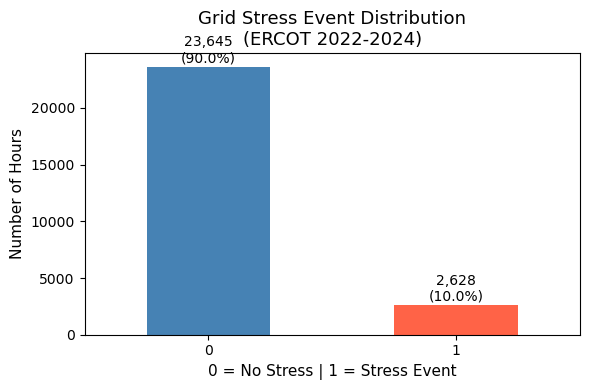

In [18]:
#Grid Stress Event Distribution 
plt.figure(figsize=(6, 4))
bars = df['grid_stress'].value_counts().sort_index().plot(
    kind='bar', 
    color=['steelblue', 'tomato']
)
plt.title('Grid Stress Event Distribution\n(ERCOT 2022-2024)', fontsize=13)
plt.xlabel('0 = No Stress | 1 = Stress Event', fontsize=11)
plt.ylabel('Number of Hours', fontsize=11)
plt.xticks(rotation=0)

# Adding count labels on top of each bar
for i, (count, pct) in enumerate(zip(stress_counts.sort_index(), stress_pct.sort_index())):
    plt.text(i, count + 100, f'{count:,}\n({pct:.1f}%)', 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('stress_distribution.png')
plt.show()

In [20]:
# Performrin Feature Transformation
# One-hot encode cloud_type from NREL (10 classes) ---
cloud_dummies = pd.get_dummies(df['cloud_type'], prefix='cloud_type')
df = pd.concat([df, cloud_dummies], axis=1)
df = df.drop(columns=['cloud_type'])
print(f'Cloud type dummies added: {cloud_dummies.columns.tolist()}')

# Defining final feature set
feature_cols = [
    # EIA demand/generation
    'demand', 'net_gen', 'solar_gen', 'wind_gen', 'nuclear_gen', 'hydro_gen',
    # Weather
    'temperature', 'windspeed_10m', 'windspeed_100m', 'cloudcover', 'shortwave_radiation',
    # NREL solar
    'ghi', 'dni', 'dhi',
    # Engineered features
    'shortfall_ratio', 'wind_variance_6h', 'ghi_baseline_30d',
    'ghi_deviation', 'demand_temp_interaction',
    # Cyclical temporal
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_week',
]

# Adding cloud type dummies (10 classes: 0-9)
cloud_cols = [c for c in df.columns if c.startswith('cloud_type_')]
feature_cols += cloud_cols

print(f'\nTotal features: {len(feature_cols)}')
print(feature_cols)

Cloud type dummies added: ['cloud_type_0', 'cloud_type_1', 'cloud_type_2', 'cloud_type_3', 'cloud_type_4', 'cloud_type_5', 'cloud_type_6', 'cloud_type_7', 'cloud_type_8', 'cloud_type_9']

Total features: 34
['demand', 'net_gen', 'solar_gen', 'wind_gen', 'nuclear_gen', 'hydro_gen', 'temperature', 'windspeed_10m', 'windspeed_100m', 'cloudcover', 'shortwave_radiation', 'ghi', 'dni', 'dhi', 'shortfall_ratio', 'wind_variance_6h', 'ghi_baseline_30d', 'ghi_deviation', 'demand_temp_interaction', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_week', 'cloud_type_0', 'cloud_type_1', 'cloud_type_2', 'cloud_type_3', 'cloud_type_4', 'cloud_type_5', 'cloud_type_6', 'cloud_type_7', 'cloud_type_8', 'cloud_type_9']


In [21]:
# Normalizaing columns, Min-Max Normalization. This is being done for continuous features only, not binary dummies
cols_to_scale = [
    'demand', 'net_gen', 'solar_gen', 'wind_gen', 'nuclear_gen', 'hydro_gen',
    'temperature', 'windspeed_10m', 'windspeed_100m', 'cloudcover', 'shortwave_radiation',
    'ghi', 'dni', 'dhi',
    'shortfall_ratio', 'wind_variance_6h', 'ghi_baseline_30d',
    'ghi_deviation', 'demand_temp_interaction'
]

scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print('Min-Max normalization applied to continuous features.')
print(f'All values now in range [0, 1]')
print(df[cols_to_scale].describe().round(3))

Min-Max normalization applied to continuous features.
All values now in range [0, 1]
          demand    net_gen  solar_gen   wind_gen  nuclear_gen  hydro_gen  \
count  26273.000  26273.000  26273.000  26273.000    26273.000  26273.000   
mean       0.355      0.359      0.048      0.072        0.804      0.020   
std        0.206      0.206      0.178      0.191        0.241      0.096   
min        0.000      0.000      0.000      0.000        0.000      0.000   
25%        0.206      0.210      0.000      0.000        0.525      0.000   
50%        0.300      0.303      0.000      0.000        0.932      0.000   
75%        0.467      0.471      0.000      0.000        0.980      0.000   
max        1.000      1.000      1.000      1.000        1.000      1.000   

       temperature  windspeed_10m  windspeed_100m  cloudcover  \
count    26273.000      26273.000       26273.000   26273.000   
mean         0.605          0.242           0.252       0.483   
std          0.176        

## Step 11 — Time-Based Train / Validation / Test Split

In [22]:
# Performing time-based split to prevent data leakage for Train/Validation/Test Split
# Random splits would allow future weather patterns to leak into training

df = df.sort_values('timestamp').reset_index(drop=True)

n = len(df)
train_end = int(n * 0.75)     # 75% training
val_end   = int(n * 0.875)    # 12.5% validation

train = df.iloc[:train_end].copy()
val   = df.iloc[train_end:val_end].copy()
test  = df.iloc[val_end:].copy()

print('Dataset Split:')
print(f'  Train:      {len(train):,} rows | {train["timestamp"].min().date()} to {train["timestamp"].max().date()}')
print(f'  Validation: {len(val):,} rows | {val["timestamp"].min().date()} to {val["timestamp"].max().date()}')
print(f'  Test:       {len(test):,} rows | {test["timestamp"].min().date()} to {test["timestamp"].max().date()}')

print(f'\nStress rate in each split:')
print(f'  Train:      {train["grid_stress"].mean()*100:.1f}%')
print(f'  Validation: {val["grid_stress"].mean()*100:.1f}%')
print(f'  Test:       {test["grid_stress"].mean()*100:.1f}%')

Dataset Split:
  Train:      19,704 rows | 2022-01-01 to 2024-04-02
  Validation: 3,284 rows | 2024-04-02 to 2024-08-17
  Test:       3,285 rows | 2024-08-17 to 2024-12-31

Stress rate in each split:
  Train:      8.7%
  Validation: 19.3%
  Test:       8.4%


In [26]:
print('\n Seasonal Bias Note:')
print('Validation set (Apr-Aug 2024) has a higher stress rate (19.3%)')
print('than Train (8.7%) due to summer peak demand concentration.')
print('This reflects real seasonal patterns in ERCOT grid operations.')
print('Model performance on validation may be optimistic for summer months.')
print('Test set stress rate (8.4%) is consistent with training, good for final evaluation.')


 Seasonal Bias Note:
Validation set (Apr-Aug 2024) has a higher stress rate (19.3%)
than Train (8.7%) due to summer peak demand concentration.
This reflects real seasonal patterns in ERCOT grid operations.
Model performance on validation may be optimistic for summer months.
Test set stress rate (8.4%) is consistent with training — good for final evaluation.


## Step 12 — Balance Training Set with SMOTE

In [34]:
# Balancing Training Set with SMOTE
# SMOTE applied ONLY to training set
# Validation and test sets remain unbalanced

# Extracting features and target
X_train = train[feature_cols].copy()
y_train = train['grid_stress'].copy()

print(f'Before SMOTE - Stress: {y_train.sum():,} | No-Stress: {(y_train==0).sum():,}')
print(f'Stress rate before SMOTE: {y_train.mean()*100:.1f}%')

# Fixing NaN and Inf values before SMOTE
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_train = X_train.fillna(0)

# Applying SMOTE
# sampling_strategy=0.43 achieves ~30% stress / 70% no-stress ratio
smote = SMOTE(sampling_strategy=0.43, random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

stress_after = y_train_bal.sum()
total_after = len(y_train_bal)
print(f'\nAfter SMOTE  - Stress: {stress_after:,} | No-Stress: {total_after - stress_after:,}')
print(f'Stress rate after SMOTE: {stress_after/total_after*100:.1f}%')

# Combining back for saving
train_balanced = pd.DataFrame(X_train_bal, columns=feature_cols)
train_balanced['grid_stress'] = y_train_bal.values

print(f'\nFinal training shape: {train_balanced.shape}')

Before SMOTE - Stress: 1,719 | No-Stress: 17,985
Stress rate before SMOTE: 8.7%

After SMOTE  - Stress: 7,733 | No-Stress: 17,985
Stress rate after SMOTE: 30.1%

Final training shape: (25718, 35)


In [36]:
# Saving to S3
def save_to_s3(df_to_save, key):
    csv_buffer = StringIO()
    df_to_save.to_csv(csv_buffer, index=False)
    s3.put_object(Bucket=BUCKET, Key=key, Body=csv_buffer.getvalue())
    print(f'Saved: s3://{BUCKET}/{key} ({len(df_to_save):,} rows)')

# Preparing val and test sets
X_val  = val[feature_cols + ['grid_stress']]
X_test = test[feature_cols + ['grid_stress']]

# Saving all splits
save_to_s3(train_balanced, 'prepared/train.csv')
save_to_s3(X_val,          'prepared/validation.csv')
save_to_s3(X_test,         'prepared/test.csv')

print('\n All datasets saved to S3 under s3://gridsense-azhuk-test/prepared/')

Saved: s3://gridsense-azhuk-test/prepared/train.csv (25,718 rows)
Saved: s3://gridsense-azhuk-test/prepared/validation.csv (3,284 rows)
Saved: s3://gridsense-azhuk-test/prepared/test.csv (3,285 rows)

 All datasets saved to S3 under s3://gridsense-azhuk-test/prepared/


In [39]:
# Summary
print('=' * 55)
print('GRIDSENSE AI — DATA PREPARATION COMPLETE')
print('=' * 55)
print(f'Total merged records:     {len(df):,}')
print(f'Total features:           {len(feature_cols)}')
print(f'Target variable:          grid_stress (binary 0/1)')
print(f'')
print(f'Train set (SMOTE):        {len(train_balanced):,} rows')
print(f'Validation set:           {len(X_val):,} rows')
print(f'Test set:                 {len(X_test):,} rows')
print(f'')
print(f'Saved to S3:')
print(f'  s3://gridsense-azhuk-test/prepared/train.csv')
print(f'  s3://gridsense-azhuk-test/prepared/validation.csv')
print(f'  s3://gridsense-azhuk-test/prepared/test.csv')
print('=' * 55)

GRIDSENSE AI — DATA PREPARATION COMPLETE
Total merged records:     26,273
Total features:           34
Target variable:          grid_stress (binary 0/1)

Train set (SMOTE):        25,718 rows
Validation set:           3,284 rows
Test set:                 3,285 rows

Saved to S3:
  s3://gridsense-azhuk-test/prepared/train.csv
  s3://gridsense-azhuk-test/prepared/validation.csv
  s3://gridsense-azhuk-test/prepared/test.csv
